In [1]:
#library import
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

In [2]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [3]:
#dataset loading
file_path = "/content/drive/MyDrive/Rajdeep_Document/data/Task_1/GWSD.tsv"

df = pd.read_csv(file_path, sep="\t")

print("Shape:", df.shape)
display(df.head())

Shape: (2300, 18)


,Unnamed: 0,round,batch,sent_id,sentence,worker_0,worker_1,worker_2,worker_3,worker_4,worker_5,worker_6,worker_7,disagree,agree,neutral,guid,in_held_out_test
0,0,1,0,s0,Global warming is a hoax.,disagrees,disagrees,disagrees,disagrees,disagrees,disagrees,disagrees,disagrees,NaN,NaN,NaN,1_0_s0,False
1,1,1,0,s1,Alarming levels of sea level rise are predicte...,neutral,neutral,neutral,agrees,agrees,neutral,neutral,agrees,NaN,NaN,NaN,1_0_s1,False
2,2,1,0,s2,"Over the past several years, the United States...",neutral,neutral,neutral,neutral,neutral,neutral,neutral,neutral,NaN,NaN,NaN,1_0_s2,False
3,3,1,0,s3,Global warming is happening and it will be dan...,agrees,agrees,agrees,agrees,agrees,agrees,agrees,agrees,NaN,NaN,NaN,1_0_s3,False
4,4,1,0,s4,Some icebergs are cute.,neutral,neutral,neutral,neutral,neutral,neutral,neutral,neutral,NaN,NaN,NaN,1_0_s4,False


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2300 entries, 0 to 2299
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Unnamed: 0        2300 non-null   int64  
 1   round             2300 non-null   int64  
 2   batch             2300 non-null   int64  
 3   sent_id           2300 non-null   object 
 4   sentence          2300 non-null   object 
 5   worker_0          2300 non-null   object 
 6   worker_1          2300 non-null   object 
 7   worker_2          2300 non-null   object 
 8   worker_3          2300 non-null   object 
 9   worker_4          2300 non-null   object 
 10  worker_5          2300 non-null   object 
 11  worker_6          2300 non-null   object 
 12  worker_7          2300 non-null   object 
 13  disagree          2050 non-null   float64
 14  agree             2050 non-null   float64
 15  neutral           2050 non-null   float64
 16  guid              2300 non-null   object 


### Raw Dataset Word Count Analysis

In [5]:
raw_all_words = " ".join(df["sentence"].astype(str)).lower().split()
raw_unique_words = len(set(raw_all_words))

print("Total words in raw dataset:", len(raw_all_words))
print("Unique words in raw dataset:", raw_unique_words)

Total words in raw dataset: 41713
Unique words in raw dataset: 6692


In [6]:
worker_cols = [col for col in df.columns if "worker_" in col]

def get_label_from_workers(row):
    votes = {"support": 0, "against": 0, "neutral": 0}

    for col in worker_cols:
        val = row[col]

        if val == "agrees":
            votes["support"] += 1
        elif val == "disagrees":
            votes["against"] += 1
        elif val == "neutral":
            votes["neutral"] += 1

    return max(votes, key=votes.get)

df["label"] = df.apply(get_label_from_workers, axis=1)

In [7]:
display(df.head())

,Unnamed: 0,round,batch,sent_id,sentence,worker_0,worker_1,worker_2,worker_3,worker_4,worker_5,worker_6,worker_7,disagree,agree,neutral,guid,in_held_out_test,label
0,0,1,0,s0,Global warming is a hoax.,disagrees,disagrees,disagrees,disagrees,disagrees,disagrees,disagrees,disagrees,NaN,NaN,NaN,1_0_s0,False,against
1,1,1,0,s1,Alarming levels of sea level rise are predicte...,neutral,neutral,neutral,agrees,agrees,neutral,neutral,agrees,NaN,NaN,NaN,1_0_s1,False,neutral
2,2,1,0,s2,"Over the past several years, the United States...",neutral,neutral,neutral,neutral,neutral,neutral,neutral,neutral,NaN,NaN,NaN,1_0_s2,False,neutral
3,3,1,0,s3,Global warming is happening and it will be dan...,agrees,agrees,agrees,agrees,agrees,agrees,agrees,agrees,NaN,NaN,NaN,1_0_s3,False,support
4,4,1,0,s4,Some icebergs are cute.,neutral,neutral,neutral,neutral,neutral,neutral,neutral,neutral,NaN,NaN,NaN,1_0_s4,False,neutral


In [8]:
df["label"].value_counts()

,count
label,
support,939
neutral,931
against,430


In [9]:
label_mapping = {'against': 0, 'neutral': 1, 'support': 2}
df2 = df[["sentence", "label"]].copy()
df2 = df2.rename(columns={'sentence': 'text'})
df2['label_id'] = df2['label'].map(label_mapping)
pd.set_option('display.max_colwidth', None)
display(df2.sample(10))

,text,label,label_id
112,And that’s not the only way global warming causes psychological problems.,support,2
1697,"Climate change seemed like a godsend for Kiribati, the Pacific island nation threatened by rising seas.",neutral,1
2078,They will do little for renewable growth and next to nothing to address climate change.,support,2
335,"The last time in Earth&apos;s geologic history that carbon dioxide is this high, there is no year-round sea ice in Antarctica.",neutral,1
1993,About two-thirds of the readers we heard from across the country wanted the next president to aggressively try to head off a climate catastrophe.,support,2
42,Putting a price on carbon dioxide emissions would be central for getting global warming under control.,support,2
1437,Solar activity has varied a bit while global temperature keeps going up.,neutral,1
487,"Over the past several years, the United States has seen an increase in business growth that has counteracted the lingering effects of the recession.",neutral,1
1880,The frightening speed of climate change is particularly visible in the Arctic.,support,2
2159,Exxon Mobil had engaged in fraud through its statements about how it accounted for the costs of climate change regulation.,neutral,1


In [10]:
# Remove the original 'label' column and rename 'label_id' to 'label'
df2 = df2.drop(columns=['label'])
df2 = df2.rename(columns={'label_id': 'label'})

print("DataFrame after dropping original 'label' and renaming 'label_id':")
display(df2.head())
df2.info()

DataFrame after dropping original 'label' and renaming 'label_id':


,text,label
0,Global warming is a hoax.,0
1,Alarming levels of sea level rise are predicted to threaten Florida over the next decades.,1
2,"Over the past several years, the United States has seen an increase in business growth that has counteracted the lingering effects of the recession.",1
3,Global warming is happening and it will be dangerous to human health and welfare.,2
4,Some icebergs are cute.,1


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2300 entries, 0 to 2299
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    2300 non-null   object
 1   label   2300 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 36.1+ KB


In [11]:
#missing value checking
df2.isnull().sum()

,0
text,0
label,0


In [12]:
#class imbalance checking
df["label"].value_counts(normalize=True) * 100

,proportion
label,
support,40.826087
neutral,40.478261
against,18.695652


In [13]:
#duplicate handling
print("Duplicates before:", df2.duplicated().sum())

df2 = df2.drop_duplicates()

print("Duplicates after:", df2.duplicated().sum())
print("New shape:", df2.shape)

Duplicates before: 251
Duplicates after: 0
New shape: (2049, 2)


In [14]:
print("Label distribution after duplicate removal:")
display(df2["label"].value_counts())

Label distribution after duplicate removal:


,count
label,
2,845
1,826
0,378


In [ ]:
#Text analysis
df2["text_length"] = df2["text"].apply(len)

df2["text_length"].describe()

,text_length
count,2049.000000
mean,114.429966
std,55.676750
min,21.000000
25%,72.000000
50%,104.000000
75%,147.000000
max,347.000000


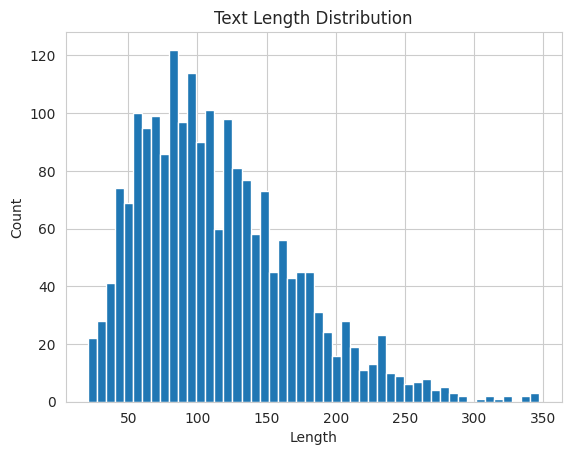

In [ ]:
import matplotlib.pyplot as plt

plt.hist(df2["text_length"], bins=50)
plt.title("Text Length Distribution")
plt.xlabel("Length")
plt.ylabel("Count")
plt.show()

In [ ]:
!pip install wordcloud

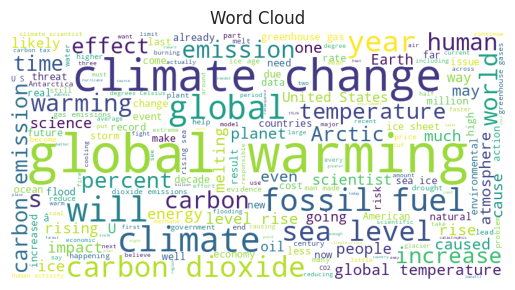

In [ ]:
from wordcloud import WordCloud

text = " ".join(df2["text"])

wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)

plt.imshow(wordcloud)
plt.axis("off")
plt.title("Word Cloud")
plt.show()

In [ ]:
#Topic distribution
from collections import Counter

stopwords = set(["the", "is", "and", "of", "to", "in", "a", "that", "it", "for", "on","are","by"])

def get_top_words(label):
    text = " ".join(df2[df2["label"] == label]["text"])
    words = text.lower().split()

    words = [w for w in words if w not in stopwords]

    return Counter(words).most_common(10)

In [ ]:
print("Support:", get_top_words("support"))
print("Neutral:", get_top_words("neutral"))
print("Against:", get_top_words("against"))

Support: [('global', 361), ('climate', 305), ('warming', 214), ('change', 126), ('be', 124), ('will', 111), ('more', 99), ('we', 97), ('carbon', 94), ('sea', 93)]
Neutral: [('global', 266), ('carbon', 193), ('climate', 179), ('warming', 100), ('from', 91), ('be', 89), ('ice', 83), ('will', 81), ('as', 80), ('emissions', 80)]
Against: [('global', 207), ('warming', 144), ('climate', 130), ('not', 66), ('carbon', 49), ('have', 47), ('as', 42), ('has', 41), ('warming.', 40), ('be', 40)]


In [ ]:
total_words = df2["text"].astype(str).str.split().str.len().sum()
print("Total number of words:", total_words)

Total number of words: 38621


In [ ]:
all_words = " ".join(df2["text"].astype(str)).lower().split()
unique_words = len(set(all_words))

print("Total words:", len(all_words))
print("Unique words:", unique_words)

Total words: 38621
Unique words: 6692


In [ ]:
#save the dataset
save_path = "/content/drive/MyDrive/Rajdeep_Document/data/Task_1/cleaned_task1.csv"

df2.to_csv(save_path, index=False)

print("Dataset saved at:", save_path)

Dataset saved at: /content/drive/MyDrive/Rajdeep_Document/data/Task_1/cleaned_task1.csv
